# OcuScan AI — Training Notebook

**Phase 2 deliverable — Day 13**

Visualises training curves, per-class F1 progression, and Phase 1 vs Phase 2 comparison.

Run `python src/train.py --phase 1` then `python src/train.py --phase 2` first.
Results are loaded from `results/phase1_history.json` and `results/phase2_history.json`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('.').resolve()
if (PROJECT_ROOT / 'src').exists():
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
else:
    PROJECT_ROOT = PROJECT_ROOT.parent
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from dataset import CLASS_NAMES

# ── Colour palette (matches OcuScan banner colours) ───────────────────────────
CLASS_COLOURS = {
    'normal':         '#2E7D32',
    'ocp':            '#F57C00',
    'ocp_chronic':    '#C62828',
    'post_viral_ded': '#1565C0',
    'sjs':            '#FF6F00',
    'symblepharon':   '#B71C1C',
}
print('Imports OK. PROJECT_ROOT:', PROJECT_ROOT)

Imports OK. PROJECT_ROOT: C:\Users\gkv47\Downloads\projectai


In [2]:
# ── Load training history ─────────────────────────────────────────────────────
def load_history(phase: int) -> pd.DataFrame | None:
    path = RESULTS_DIR / f'phase{phase}_history.json'
    if not path.exists():
        print(f'  [INFO] {path.name} not found — run train.py first.')
        return None
    with open(path) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print(f'  Phase {phase}: {len(df)} epochs loaded from {path.name}')
    return df

df1 = load_history(1)
df2 = load_history(2)

  Phase 1: 10 epochs loaded from phase1_history.json
  Phase 2: 8 epochs loaded from phase2_history.json


Saved → C:\Users\gkv47\Downloads\projectai\results\training_curves.png


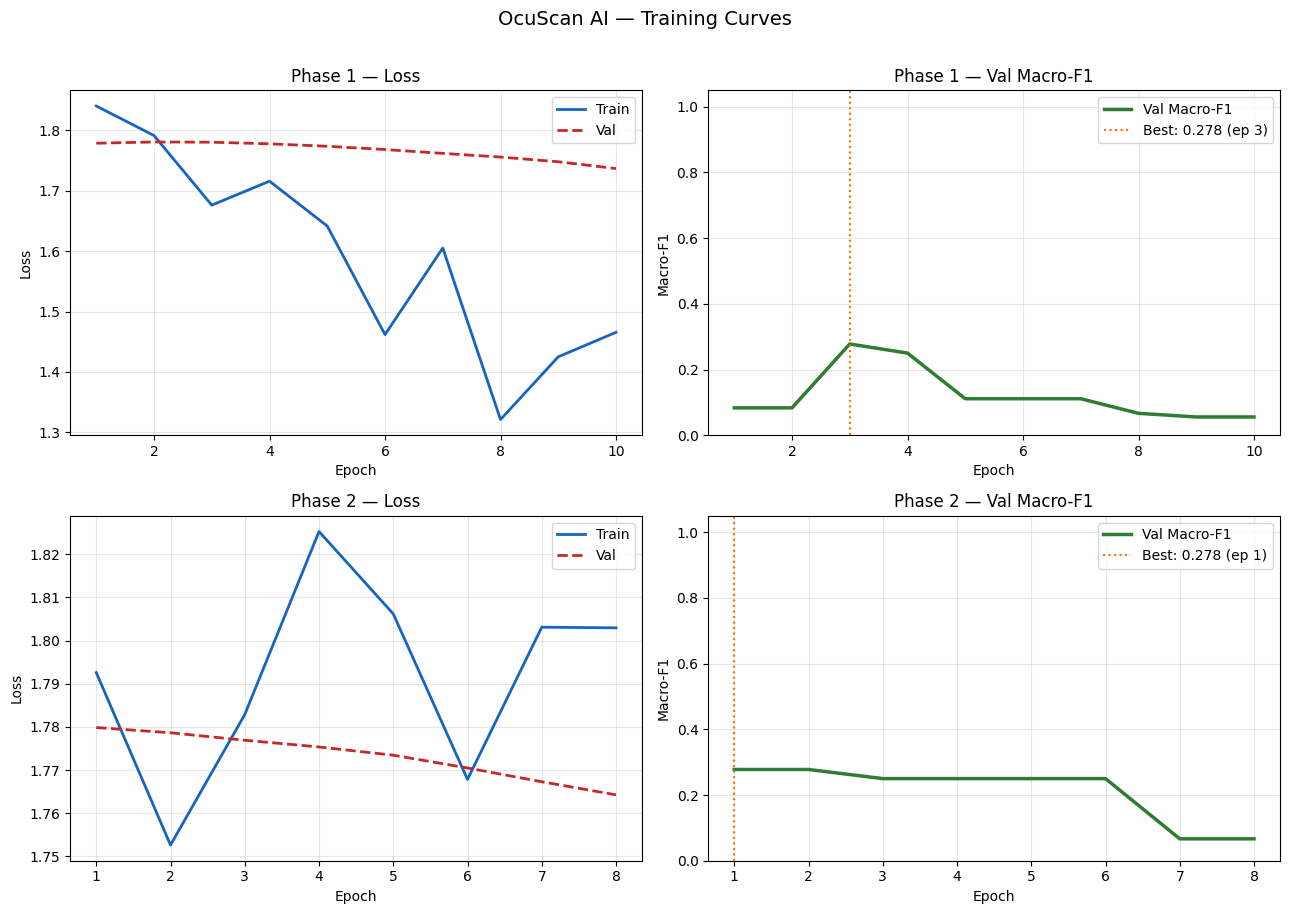

In [3]:
# ── Figure 1: Loss & Macro-F1 curves (per phase) ─────────────────────────────
def plot_training_curves(df: pd.DataFrame, phase: int, ax_loss, ax_f1):
    epochs = df['epoch']
    ax_loss.plot(epochs, df['train_loss'], label='Train', color='#1565C0', linewidth=2)
    ax_loss.plot(epochs, df['val_loss'],   label='Val',   color='#C62828', linewidth=2, linestyle='--')
    ax_loss.set_title(f'Phase {phase} — Loss', fontsize=12)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_f1.plot(epochs, df['val_macro_f1'], color='#2E7D32', linewidth=2.5, label='Val Macro-F1')
    best_idx = df['val_macro_f1'].idxmax()
    ax_f1.axvline(df.loc[best_idx, 'epoch'], color='#FF6F00', linestyle=':', linewidth=1.5,
                  label=f"Best: {df.loc[best_idx,'val_macro_f1']:.3f} (ep {int(df.loc[best_idx,'epoch'])})")
    ax_f1.set_title(f'Phase {phase} — Val Macro-F1', fontsize=12)
    ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel('Macro-F1')
    ax_f1.set_ylim(0, 1.05); ax_f1.legend(); ax_f1.grid(alpha=0.3)

phases = [(df1, 1), (df2, 2)]
available = [(df, p) for df, p in phases if df is not None]

if available:
    fig, axes = plt.subplots(len(available), 2, figsize=(13, 4.5 * len(available)))
    if len(available) == 1:
        axes = [axes]
    for (df, phase), row_axes in zip(available, axes):
        plot_training_curves(df, phase, row_axes[0], row_axes[1])
    plt.suptitle('OcuScan AI — Training Curves', fontsize=14, y=1.01)
    plt.tight_layout()
    out = RESULTS_DIR / 'training_curves.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()
else:
    print('No history files found. Run train.py first.')

Saved → C:\Users\gkv47\Downloads\projectai\results\per_class_f1_bar.png


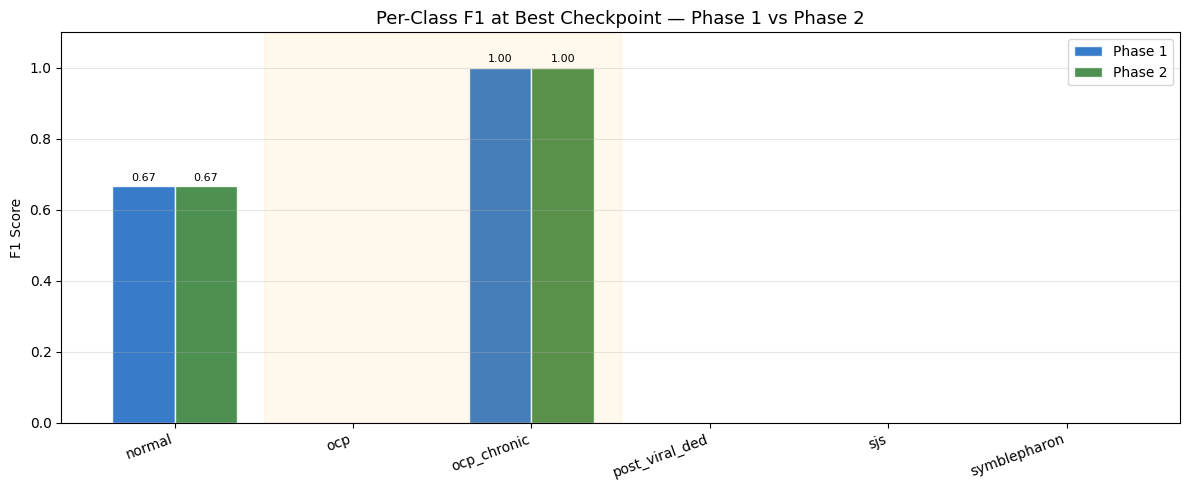

In [4]:
# ── Figure 2: Per-class F1 bar chart (best epoch of each phase) ───────────────
def get_best_epoch_row(df: pd.DataFrame) -> pd.Series:
    return df.loc[df['val_macro_f1'].idxmax()]

f1_cols = [f'val_f1_{cls}' for cls in CLASS_NAMES]

rows = {}
if df1 is not None:
    rows['Phase 1'] = get_best_epoch_row(df1)[f1_cols].values
if df2 is not None:
    rows['Phase 2'] = get_best_epoch_row(df2)[f1_cols].values

if rows:
    x = np.arange(len(CLASS_NAMES))
    width = 0.35 if len(rows) == 2 else 0.5
    offsets = [-width/2, width/2] if len(rows) == 2 else [0]
    phase_colours = ['#1565C0', '#2E7D32']

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (label, vals) in enumerate(rows.items()):
        bars = ax.bar(x + offsets[i], vals, width, label=label,
                      color=phase_colours[i], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0.05:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1)
    ax.set_title('Per-Class F1 at Best Checkpoint — Phase 1 vs Phase 2', fontsize=13)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # Highlight the hardest pair
    ocp_idx  = CLASS_NAMES.index('ocp')
    ocpc_idx = CLASS_NAMES.index('ocp_chronic')
    ax.axvspan(ocp_idx - 0.5, ocpc_idx + 0.5, alpha=0.07, color='orange',
               label='OCP discrimination zone')

    plt.tight_layout()
    out = RESULTS_DIR / 'per_class_f1_bar.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

In [5]:
# ── Figure 3: Phase 1 vs Phase 2 comparison summary table ─────────────────────
if df1 is not None and df2 is not None:
    r1 = get_best_epoch_row(df1)
    r2 = get_best_epoch_row(df2)

    metrics = [
        ('val_macro_f1',        'Macro F1'),
        ('val_accuracy',        'Accuracy'),
        ('val_sjs_recall',      'SJS Recall'),
        ('val_ocp_f1',          'OCP F1'),
        ('val_ocp_chronic_f1',  'OCP Chronic F1'),
        ('val_symblepharon_f1', 'Symblepharon F1'),
    ]

    print('\n  Phase 1 vs Phase 2 — Best Checkpoint Comparison')
    print(f'  {"Metric":<22} {"Phase 1":>10} {"Phase 2":>10} {"Δ":>8}')
    print('  ' + '-' * 53)
    for col, label in metrics:
        v1 = r1.get(col, float('nan'))
        v2 = r2.get(col, float('nan'))
        delta = v2 - v1 if not (np.isnan(v1) or np.isnan(v2)) else float('nan')
        sign = '+' if delta > 0 else ''
        print(f'  {label:<22} {v1:>10.4f} {v2:>10.4f} {sign}{delta:>7.4f}')

    # Save as JSON for MLflow
    comparison = {
        f'phase1_{col}': float(r1.get(col, 0)) for col, _ in metrics
    }
    comparison.update({
        f'phase2_{col}': float(r2.get(col, 0)) for col, _ in metrics
    })
    with open(RESULTS_DIR / 'phase_comparison.json', 'w') as f:
        json.dump(comparison, f, indent=2)
    print('\n  Saved → results/phase_comparison.json')


  Phase 1 vs Phase 2 — Best Checkpoint Comparison
  Metric                    Phase 1    Phase 2        Δ
  -----------------------------------------------------
  Macro F1                   0.2778     0.2778  0.0000
  Accuracy                   0.3333     0.3333  0.0000
  SJS Recall                 0.0000     0.0000  0.0000
  OCP F1                     0.0000     0.0000  0.0000
  OCP Chronic F1             1.0000     1.0000  0.0000
  Symblepharon F1            0.0000     0.0000  0.0000

  Saved → results/phase_comparison.json


Saved → C:\Users\gkv47\Downloads\projectai\results\ocp_discrimination_curve.png


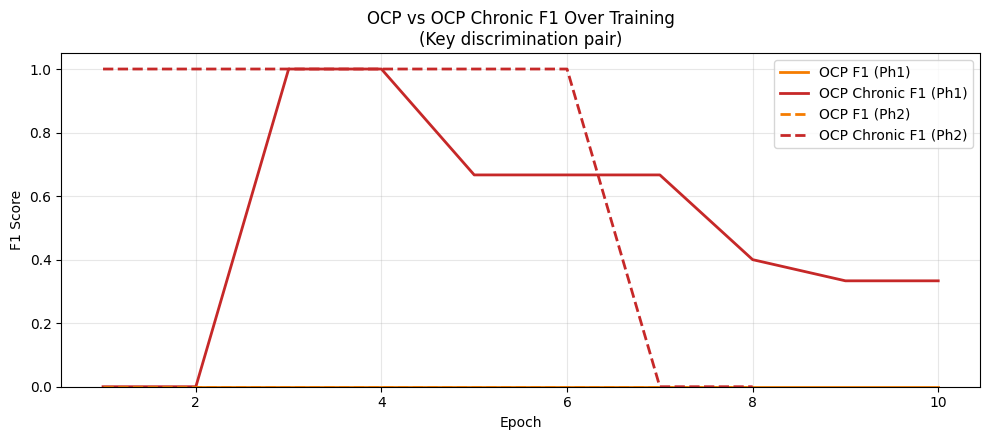

In [6]:
# ── Figure 4: OCP / OCP Chronic F1 over epochs (hardest discrimination) ───────
if df1 is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for df, phase, ls in [(df1, 1, '-'), (df2, 2, '--')]:
        if df is None:
            continue
        epochs = df['epoch']
        if 'val_f1_ocp' in df.columns:
            ax.plot(epochs, df['val_f1_ocp'],
                    color='#F57C00', linestyle=ls, linewidth=2,
                    label=f'OCP F1 (Ph{phase})')
        if 'val_f1_ocp_chronic' in df.columns:
            ax.plot(epochs, df['val_f1_ocp_chronic'],
                    color='#C62828', linestyle=ls, linewidth=2,
                    label=f'OCP Chronic F1 (Ph{phase})')

    ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
    ax.set_title('OCP vs OCP Chronic F1 Over Training\n(Key discrimination pair)', fontsize=12)
    ax.legend()
    plt.tight_layout()
    out = RESULTS_DIR / 'ocp_discrimination_curve.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

Saved → C:\Users\gkv47\Downloads\projectai\results\phase1_lr_schedule.png


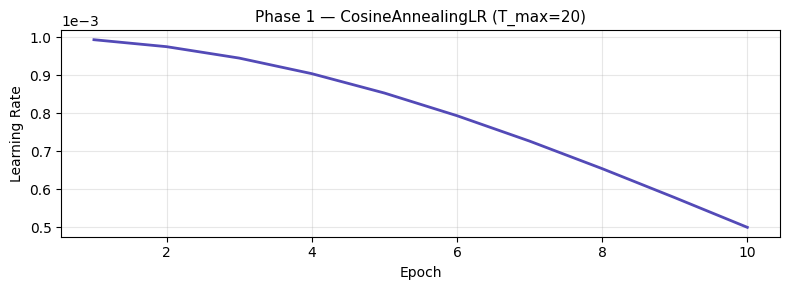

Saved → C:\Users\gkv47\Downloads\projectai\results\phase2_lr_schedule.png


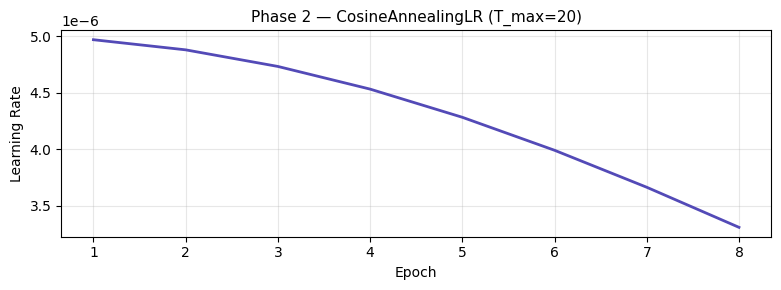

In [7]:
# ── Figure 5: Learning rate schedule ──────────────────────────────────────────
for df, phase in [(df1, 1), (df2, 2)]:
    if df is None or 'lr' not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(df['epoch'], df['lr'], color='#534AB7', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title(f'Phase {phase} — CosineAnnealingLR (T_max=20)', fontsize=11)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.tight_layout()
    out = RESULTS_DIR / f'phase{phase}_lr_schedule.png'
    plt.savefig(out, dpi=100, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

In [8]:
# ── Overfitting diagnostic ─────────────────────────────────────────────────────
# RED FLAG: if train_acc → 1.0 while val_macro_f1 stays low, model is memorising
for df, phase in [(df1, 1), (df2, 2)]:
    if df is None:
        continue
    final = df.iloc[-1]
    best_f1 = df['val_macro_f1'].max()
    best_epoch = df.loc[df['val_macro_f1'].idxmax(), 'epoch']
    final_train_acc = final.get('train_acc', float('nan'))
    final_val_f1 = final.get('val_macro_f1', float('nan'))

    gap = final_train_acc - final_val_f1
    flag = '⚠ OVERFIT' if gap > 0.4 else '✓ OK'

    print(f'Phase {phase} | Best F1: {best_f1:.4f} @ epoch {int(best_epoch)} | '
          f'Final train acc: {final_train_acc:.3f} | Final val F1: {final_val_f1:.4f} | '
          f'Gap: {gap:.3f} {flag}')

print('\nNotebook complete. All figures saved to results/.')

Phase 1 | Best F1: 0.2778 @ epoch 3 | Final train acc: 0.573 | Final val F1: 0.0556 | Gap: 0.518 ⚠ OVERFIT
Phase 2 | Best F1: 0.2778 @ epoch 1 | Final train acc: 0.249 | Final val F1: 0.0667 | Gap: 0.182 ✓ OK

Notebook complete. All figures saved to results/.
